In [1]:
%load_ext autoreload
%autoreload 2

# Energy yield example
This notebook shows an example for energy yield simulations of tandem devices for a single location.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pvcircuit as pvc
import ipywidgets as widgets
import zipfile
import pytz
from pathlib import Path
import re
from pvcircuit import EQE
from scipy.integrate import trapezoid

#### Helper

In [3]:
# Load NSRDB file
def load_nsrdb(filepath):

    with zipfile.ZipFile(filepath) as zip_file:
        files = zip_file.namelist()
        with zip_file.open(files[0]) as csv_file:
            meta = pd.read_csv(csv_file, nrows=1, header=0)
        with zip_file.open(files[0]) as csv_file:
            data = pd.read_csv(csv_file, header=2)

        data["timestamp"] = pd.to_datetime(data[["Year", "Month", "Day", "Hour", "Minute"]], utc=True)
        offset_timezone = pytz.FixedOffset(int(meta["Local Time Zone"][0] * 60))
        data["timestamp"] = data["timestamp"].dt.tz_convert(offset_timezone)

        data.set_index("timestamp", inplace=True)

        meteo = data.iloc[:, :32]
        spectra = data.iloc[:, 32:] / 1e3  # convert from W/m^2/um to W/m^2/nm
        wavelength = spectra.columns.str.extract(r"(\d+\.\d+)", expand=True).astype(float).values.flatten() * 1e3

        return wavelength, spectra, meteo

Load EQE

In [4]:
tc_eqe_file = Path(r"../data/PSC_EQE.csv")
bc_eqe_file = Path(r"../data/Si_EQE.csv")


In [5]:
tc_eqe = np.loadtxt(tc_eqe_file,delimiter=",",skiprows=1)
bc_eqe = np.loadtxt(bc_eqe_file,delimiter=",",skiprows=1)

In [6]:
tandem_eqe = pvc.EQE(tc_eqe[:,0], tc_eqe[:,1])
tandem_eqe.add_eqe(bc_eqe[:,0], bc_eqe[:,1])
tandem_eqe.add_spectra(pvc.qe.wvl,pvc.qe.AM15G)


(<Axes: title={'center': 'EQE EQE'}, xlabel='Wavelength (nm)', ylabel='EQE'>,
 <Axes: ylabel='Irradiance (W/m2/nm)'>)

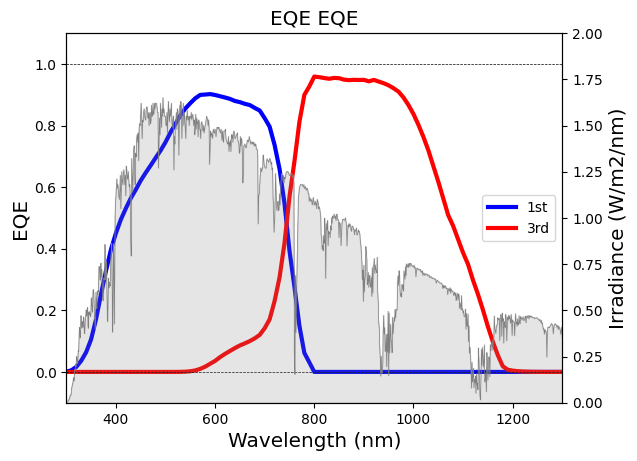

In [7]:
tandem_eqe.plot()

In [8]:
tandem_bandgaps, tandem_sigmas = tandem_eqe.calc_Eg_Rau()
psc_bandgap_25 = tandem_bandgaps[0]
psc_sigma_25 = tandem_sigmas[0]
si_bandgap_25 = tandem_bandgaps[1]
si_sigma_25 = tandem_sigmas[1]


tandem_eqe.add_spectra()
tandem_jsc = tandem_eqe.Jint()
psc_jsc = tandem_jsc[0]
si_jsc = tandem_jsc[1]

Load diode paramters

In [9]:
dev3T = pvc.Tandem3T()
dev3T.set(name="PskSiTandem", Rz=0)
dev3T.top.set(Eg=psc_bandgap_25, J0ratio=[350], Jext=psc_jsc * 1e-3, Gsh=3.6e-4, Rser=1.12, n=[1.78], beta=0)
dev3T.bot.set(Eg=si_bandgap_25, J0ratio=[1600], Jext=si_jsc * 1e-3, Gsh=1.3e-4, Rser=0.84, n=[1.38], beta=0)
print(dev3T)

PskSiTandem: <pvcircuit.tandem3T.Tandem3T class>
T = 25.0 C, Rz= 0 Ω cm2, Rt= 1.12 Ω cm2, Rr = 0.84 Ω cm2

top: <pvcircuit.junction.Junction class>
Eg = 1.66 eV, TC = 25.0 C
Jext = 18.2 mA/cm2, JLC = 0.0 mA/cm2
Gsh = 0.00036 S/cm2, Rser = 1.12 Ωcm2
lightA = 1 cm2, totalA = 1 cm2
pn = -1, beta = 0, gamma = 0
   n    J0ratio   J0(A/cm2) 
  db       1      1.109e-25 
 1.78    350.00   1.621e-13 

bot: <pvcircuit.junction.Junction class>
Eg = 1.15 eV, TC = 25.0 C
Jext = 18.1 mA/cm2, JLC = 0.0 mA/cm2
Gsh = 0.00013 S/cm2, Rser = 0.84 Ωcm2
lightA = 1 cm2, totalA = 1 cm2
pn = 1, beta = 0, gamma = 0
   n    J0ratio   J0(A/cm2) 
  db       1      2.222e-17 
 1.38   1600.00   2.044e-10 


Load environmental data

In [10]:
environmental_fp = Path("../data/2021_-105p86_39p81_fixed_tilt_30_180.nsrdb")
wavelength, spectra, meteo = load_nsrdb(environmental_fp)

# add spectra to EQE class to calculate current densities
tandem_eqe.add_spectra(wavelength,spectra.T)

# create EY class from meteorological data
ey = pvc.EY.Meteo(wavelength,spectra,meteo["Temperature"], meteo["Wind Speed"], meteo.index)

Calculate device currents

In [11]:
psc_jscs, si_jscs= ey.calc_currents(tandem_eqe)

Simulate annual energy yield for various tandem configuration

In [12]:
# eyf = ey.filter_custom(~ey.SpecPower.isna())
operation_modes = ["CM", "MPP", "VM-21-r", "VM-21-s"]
ey_results = {}
for oper in operation_modes:
    res = ey.run_ey(dev3T, oper, multiprocessing=True)
    ey_results[oper] = res



Running PskSiTandem in mode CM:   0%|          | 0/8760 [00:00<?, ?it/s]

Running with 8 parallel processes


Running PskSiTandem in mode MPP:   0%|          | 0/8760 [00:00<?, ?it/s]

Running with 8 parallel processes


Running PskSiTandem in mode VM-21-r:   0%|          | 0/8760 [00:00<?, ?it/s]

Running with 8 parallel processes


Running PskSiTandem in mode VM-21-s:   0%|          | 0/8760 [00:00<?, ?it/s]

Running with 8 parallel processes


Running PskSiTandem in mode VM-21-s: 100%|██████████| 8760/8760 [05:01<00:00, 29.02it/s]


Calculate device power

Text(0, 0.5, 'Energy harvesting efficiency (%)')

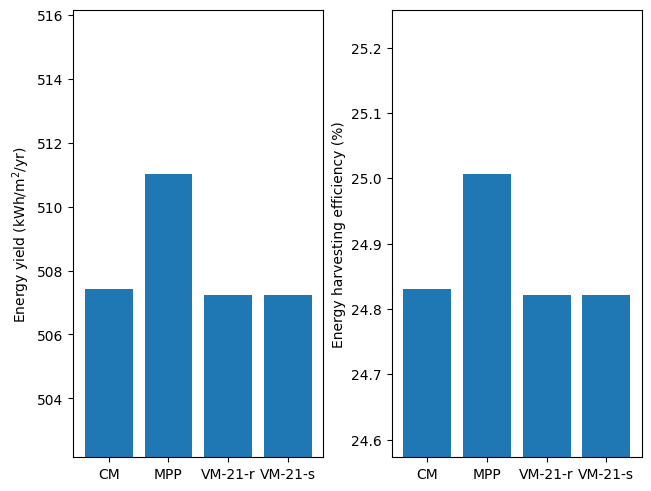

In [13]:
values = np.array(list(ey_results.values())).T  # Transpose to separate tuple elements
fig,ax = plt.subplots(1,2, constrained_layout = True)
ax[0].bar(operation_modes,values[0,:])
ax[0].set_ylim(0.99*min(values[0,:]),1.01*max(values[0,:]))
ax[0].set_ylabel(r"Energy yield (kWh/m$^2$/yr)")

ehe = values[1,:]*100
ax[1].bar(operation_modes,values[1,:]*100)
ax[1].set_ylim(0.99*min(ehe),1.01*max(ehe))
ax[1].set_ylabel(r"Energy harvesting efficiency (%)")

Consider string-end losses

In [82]:
np.cumsum(np.arange(1,30)**0.5,dtype=int)

array([ 1,  2,  3,  5,  7,  9, 11, 13, 16, 19, 22, 25, 28, 31, 34, 38, 42,
       46, 50, 54, 58, 62, 66, 70, 75, 80, 85, 90, 95])

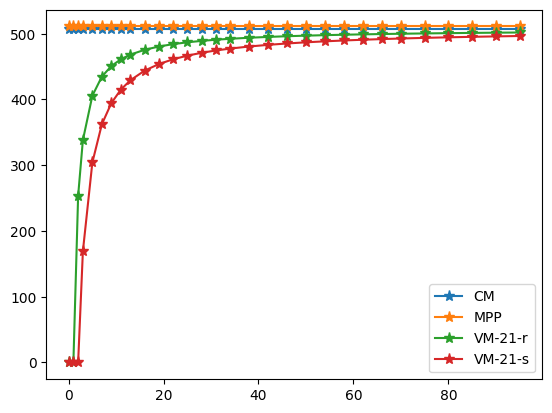

In [ ]:
cells_per_string = np.cumsum(np.arange(1,30)**0.5,dtype=int)
ey_strings = {k: [] for k in ey_results.keys()}
for nr_cells in cells_per_string:
    for k in ey_results.keys():
        lf = pvc.EY.VMloss(dev3T, k, nr_cells)
        # print(f"loss factor {lf} for {k} with {nr_cells} cells")
        ey_strings[k].append(ey_results[k][0] * lf)


fig, ax = plt.subplots()
for k, v in ey_strings.items():
    ax.plot(cells_per_string, v, "-*", ms=8, label=k)

ax.legend()